In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("college_student_placement_dataset (1).csv")

In [3]:
dataset


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [5]:
dataset["Placement"].unique()

array(['No', 'Yes'], dtype=object)

In [6]:
dataset["Placement"].nunique()

2

In [7]:
dataset["Placement"].count()

10000

In [8]:
dataset["Placement"].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

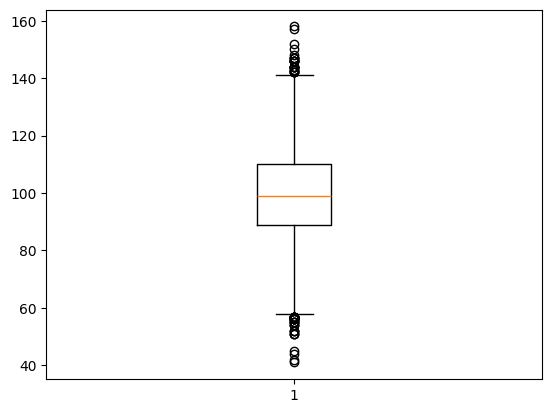

In [9]:
plt.boxplot(dataset['IQ'])
plt.show()

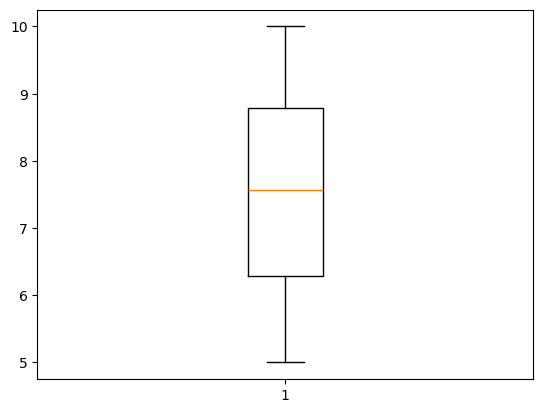

In [10]:
plt.boxplot(dataset['Prev_Sem_Result'])
plt.show()

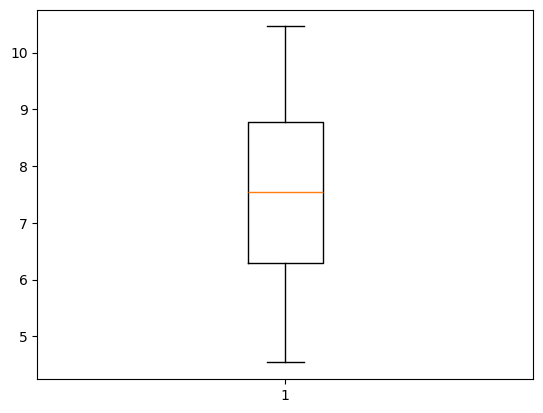

In [11]:
plt.boxplot(dataset['CGPA'])
plt.show()

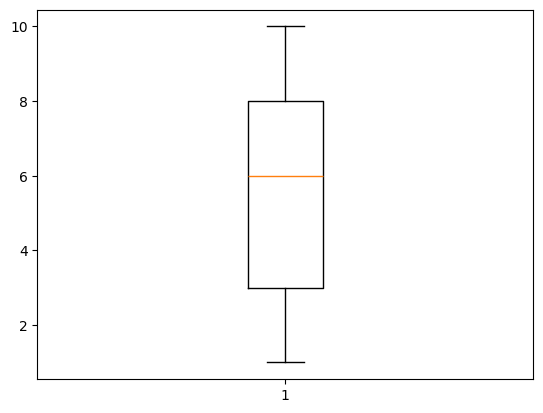

In [12]:
plt.boxplot(dataset['Academic_Performance'])
plt.show()

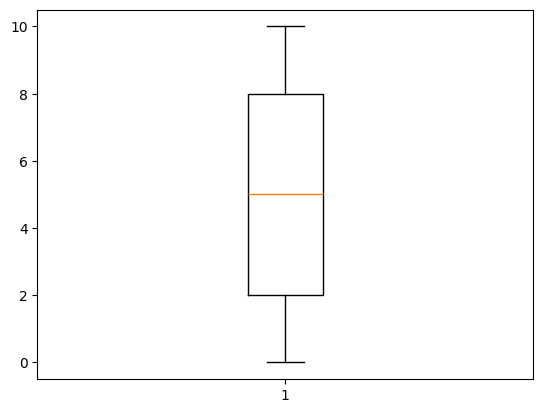

In [13]:
plt.boxplot(dataset['Extra_Curricular_Score'])
plt.show()

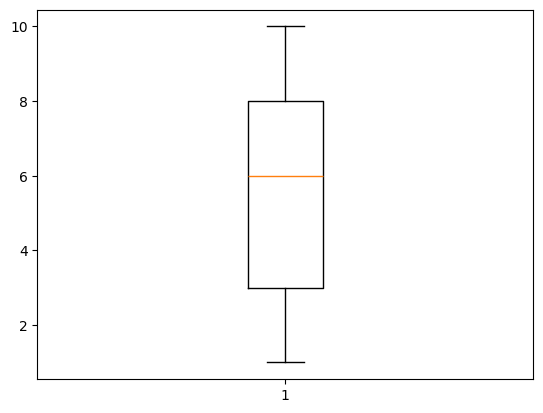

In [14]:
plt.boxplot(dataset['Communication_Skills'])
plt.show()

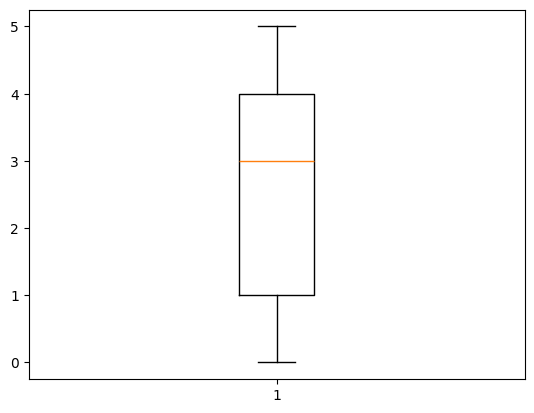

In [15]:
plt.boxplot(dataset['Projects_Completed'])
plt.show()

In [16]:
q1 = dataset['IQ'].quantile(0.25)

In [17]:
q3 = dataset['IQ'].quantile(0.75)

In [18]:
IQR = q3-q1
IQR

21.0

In [19]:
upper = q3 + (IQR*1.5)
upper

141.5

In [20]:
dataset[dataset['IQ']>upper]['IQ'].value_counts()

IQ
146    6
144    6
147    4
142    4
143    3
157    1
158    1
148    1
152    1
150    1
Name: count, dtype: int64

### Encoding

In [21]:
dataset.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['Internship_Experience']= le.fit_transform(dataset['Internship_Experience'])

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['College_ID']= le.fit_transform(dataset['College_ID'])

### Divide X & Y

In [24]:
X = dataset[["College_ID","IQ","Prev_Sem_Result","CGPA","Academic_Performance","Internship_Experience","Extra_Curricular_Score","Communication_Skills","Projects_Completed"]]

In [25]:
y = dataset["Placement"]

## Split Data Training & Testing

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=40)

## Using cross validation

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate

In [29]:
knn = KNeighborsClassifier(n_neighbors=7, metric="euclidean")
result = cross_validate(knn, X_train,y_train, cv=5, return_train_score=True)

In [30]:
result

{'fit_time': array([0.01266742, 0.00850749, 0.00882006, 0.01351571, 0.00989509]),
 'score_time': array([0.05762291, 0.04817414, 0.0453949 , 0.04861951, 0.05458665]),
 'test_score': array([0.87428571, 0.88142857, 0.88642857, 0.88142857, 0.87714286]),
 'train_score': array([0.92125   , 0.91482143, 0.91625   , 0.91464286, 0.91875   ])}

In [31]:
result["train_score"]

array([0.92125   , 0.91482143, 0.91625   , 0.91464286, 0.91875   ])

In [32]:
print("Avg Training acc after cross validation",result["train_score"].mean())

Avg Training acc after cross validation 0.917142857142857


In [33]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_trans = ss.fit_transform(X)
x_trans

array([[-0.71898339,  0.50013457, -0.63952141, ...,  0.9585926 ,
         0.84054972,  0.86638109],
       [ 0.35740662, -0.16421357, -1.39257172, ...,  0.6421314 ,
         0.84054972, -1.46479365],
       [-0.51064984,  0.6330042 , -1.50311122, ..., -0.62371336,
        -1.57264364, -0.88199997],
       ...,
       [ 0.53101791, -0.69569209, -1.00568349, ..., -0.62371336,
         1.18529163,  1.44917478],
       [-0.19814951,  0.50013457,  0.85276177, ...,  0.6421314 ,
        -0.193676  , -0.88199997],
       [ 0.32268436,  0.6330042 ,  1.29491975, ..., -0.62371336,
        -0.193676  ,  1.44917478]])

In [34]:
X = pd.DataFrame(x_trans,columns=X.columns)
X

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,-0.718983,0.500135,-0.639521,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381
1,0.357407,-0.164214,-1.392572,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794
2,-0.510650,0.633004,-1.503111,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000
3,0.149073,1.496657,-1.427115,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000
4,-1.621762,-0.230648,0.258612,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206
...,...,...,...,...,...,...,...,...,...
9995,-1.031484,1.297352,0.604048,0.515365,-0.538190,-0.810387,-1.256636,0.840550,-1.464794
9996,1.642130,-1.957954,1.184380,1.229618,0.505893,-0.810387,-1.573097,0.495808,-0.299206
9997,0.531018,-0.695692,-1.005683,-0.872327,-0.886218,1.233979,-0.623713,1.185292,1.449175
9998,-0.198150,0.500135,0.852762,0.943917,-0.886218,-0.810387,0.642131,-0.193676,-0.882000


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=40)

## Using Confusion Matrix

In [36]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
test_pred = knn.predict(X_test)

In [39]:
from sklearn. metrics import accuracy_score,confusion_matrix,precision_score,recall_score,classification_report

In [40]:
accuracy_score(y_test, test_pred) 

0.932

In [41]:
confusion_matrix(y_test,test_pred)

array([[2451,   75],
       [ 129,  345]], dtype=int64)

In [42]:
y_test.value_counts() 

Placement
No     2526
Yes     474
Name: count, dtype: int64

In [43]:
pd.Series(test_pred).value_counts()

No     2580
Yes     420
Name: count, dtype: int64

In [44]:
matrix = pd.DataFrame({"Positive":[2451,129], "Negative":[75,345]})
matrix

,Positive,Negative
0,2451,75
1,129,345


In [45]:
prec_positive = precision_score(y_test,test_pred,pos_label='No')
prec_positive

0.95

In [46]:
prec_negative = precision_score(y_test,test_pred,pos_label='Yes') 


In [47]:
prec_negative

0.8214285714285714

In [48]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

          No       0.95      0.97      0.96      2526
         Yes       0.82      0.73      0.77       474

    accuracy                           0.93      3000
   macro avg       0.89      0.85      0.87      3000
weighted avg       0.93      0.93      0.93      3000



In [49]:
train_pred = knn.predict(X_train)

In [50]:
accuracy_score(y_train, train_pred)

0.9658571428571429

In [51]:
confusion_matrix(y_train,train_pred)

array([[5736,   79],
       [ 160, 1025]], dtype=int64)

In [52]:
y_train.value_counts()

Placement
No     5815
Yes    1185
Name: count, dtype: int64

In [53]:
pd.Series(train_pred).value_counts()

No     5896
Yes    1104
Name: count, dtype: int64

In [54]:
prec_positive = precision_score(y_train,train_pred,pos_label='No')
prec_positive

0.9728629579375848

In [55]:
prec_negative = precision_score(y_train,train_pred,pos_label='Yes')

In [56]:
prec_negative

0.9284420289855072

In [57]:
print(classification_report(y_train,train_pred))

              precision    recall  f1-score   support

          No       0.97      0.99      0.98      5815
         Yes       0.93      0.86      0.90      1185

    accuracy                           0.97      7000
   macro avg       0.95      0.93      0.94      7000
weighted avg       0.97      0.97      0.97      7000



## Using SMOTE(Imbalanced Data)

In [58]:
from imblearn.under_sampling import RandomUnderSampler

In [59]:
under = RandomUnderSampler()
under_x,under_y = under.fit_resample(X_train,y_train)
under_x_test, under_y_test = under.fit_resample(X_test,y_test)

In [60]:
under_y.value_counts()

Placement
No     1185
Yes    1185
Name: count, dtype: int64

In [61]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(under_x,under_y)
pred = knn.predict(under_x_test)
accuracy_score(under_y_test,pred)

0.8924050632911392

In [62]:
under_y_test.value_counts()

Placement
No     474
Yes    474
Name: count, dtype: int64

In [63]:
precision_score(under_y_test,pred,pos_label="No")

0.9492753623188406

In [64]:
precision_score(under_y_test,pred,pos_label="Yes")

0.848314606741573

In [65]:
over = RandomUnderSampler()
over_x,over_y = over.fit_resample(X_train,y_train)
over_x_test, over_y_test = over.fit_resample(X_test,y_test)

In [66]:
over_y.value_counts()

Placement
No     1185
Yes    1185
Name: count, dtype: int64

In [67]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(over_x,over_y)
pred = knn.predict(over_x_test)
accuracy_score(over_y_test,pred)

0.8997890295358649

In [68]:
precision_score(over_y_test,pred,pos_label="No")

0.9522673031026253

In [69]:
precision_score(over_y_test,pred,pos_label="Yes")

0.8582230623818525

In [70]:
sm = RandomUnderSampler()
sm_x,sm_y = over.fit_resample(X_train,y_train)
sm_x_test, sm_y_test = sm.fit_resample(X_test,y_test)

In [71]:
sm_y.value_counts()

Placement
No     1185
Yes    1185
Name: count, dtype: int64

In [72]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
sm_x, sm_y = sm.fit_resample(X_train,y_train)
sm_test_x, sm_test_y = over.fit_resample(X_test,y_test)

In [73]:
precision_score(sm_y_test,pred,pos_label="No")

0.9522673031026253

In [74]:
precision_score(sm_y_test,pred,pos_label="Yes")

0.8582230623818525

### build the model

In [75]:
from sklearn.neighbors import KNeighborsClassifier

In [76]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [77]:
test_pred=knn.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,classification_report

In [79]:
accuracy_score(y_test, test_pred) #accuracy score

0.932

In [80]:
confusion_matrix(y_test, test_pred)

array([[2451,   75],
       [ 129,  345]], dtype=int64)

In [81]:
y_test.value_counts()

Placement
No     2526
Yes     474
Name: count, dtype: int64

In [82]:
prec_positive=precision_score(y_test, test_pred,pos_label='No')

In [83]:
prec_positive

0.95

In [84]:
prec_negative=precision_score(y_test, test_pred,pos_label='Yes')
prec_negative

0.8214285714285714

In [85]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

          No       0.95      0.97      0.96      2526
         Yes       0.82      0.73      0.77       474

    accuracy                           0.93      3000
   macro avg       0.89      0.85      0.87      3000
weighted avg       0.93      0.93      0.93      3000



In [86]:
train_pred=knn.predict(X_train)

In [87]:
accuracy_score(y_train, train_pred)

0.9658571428571429

In [88]:
confusion_matrix(y_train, train_pred)

array([[5736,   79],
       [ 160, 1025]], dtype=int64)

In [89]:
y_train.value_counts()

Placement
No     5815
Yes    1185
Name: count, dtype: int64

In [90]:
prec_positive=precision_score(y_train, train_pred,pos_label='No')

In [91]:
prec_positive

0.9728629579375848

In [92]:
prec_negative=precision_score(y_train, train_pred,pos_label='Yes')
prec_negative

0.9284420289855072

In [93]:
print(classification_report(y_train,train_pred))

              precision    recall  f1-score   support

          No       0.97      0.99      0.98      5815
         Yes       0.93      0.86      0.90      1185

    accuracy                           0.97      7000
   macro avg       0.95      0.93      0.94      7000
weighted avg       0.97      0.97      0.97      7000



In [94]:
## N=5

In [95]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

test_pred = knn.predict(X_test)
accuracy_score(y_test, test_pred) 

0.934

In [96]:
## manual way to decide k value

In [97]:
train_acc=[]
test_acc=[]
k = []
for x in range(3,16,2):
    knn = KNeighborsClassifier(n_neighbors=x)
    knn.fit(X_train,y_train)
    k.append(x)
    test_pred = knn.predict(X_test)
    train_pred = knn.predict(X_train)
    test_acc.append(accuracy_score(y_test, test_pred))
    train_acc.append(accuracy_score(y_train, train_pred))

In [98]:
train_acc

[0.9658571428571429,
 0.9548571428571428,
 0.9508571428571428,
 0.9451428571428572,
 0.9432857142857143,
 0.9404285714285714,
 0.9344285714285714]

In [99]:
test_acc

[0.932,
 0.934,
 0.9336666666666666,
 0.9376666666666666,
 0.937,
 0.935,
 0.9323333333333333]

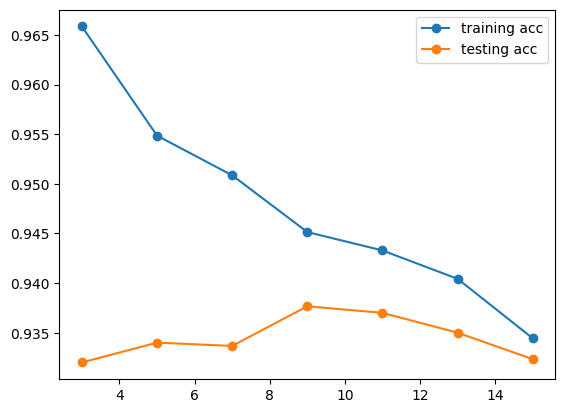

In [100]:
plt.plot(k,train_acc,marker='o')
plt.plot(k,test_acc,marker='o')
plt.legend(["training acc", "testing acc"])

## Using Gridsearch CV

In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [102]:
# knn= KNeighborsClassifier(metric='')

In [103]:
knn = KNeighborsClassifier()
param = {'n_neighbors':np.arange(3,16,2),'metric':['euclidean','manhattan', 'minkowski']}

gcv = GridSearchCV(knn,param,verbose=4,return_train_score=True)
gcv.fit(X_train,y_train)

Fitting 5 folds for each of 21 candidates, totalling 105 fits
[CV 1/5] END metric=euclidean, n_neighbors=3;, score=(train=0.966, test=0.915) total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3;, score=(train=0.966, test=0.916) total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=3;, score=(train=0.962, test=0.919) total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3;, score=(train=0.963, test=0.924) total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3;, score=(train=0.964, test=0.921) total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=5;, score=(train=0.953, test=0.922) total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=5;, score=(train=0.952, test=0.924) total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=5;, score=(train=0.955, test=0.919) total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=5;, score=(train=0.954, test=0.930) total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=5;, score=(tr

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': array([ 3,  5,  7,  9, 11, 13, 15])},
             return_train_score=True, verbose=4)

In [104]:
pd.DataFrame(gcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.009586,0.001202,0.076562,0.010249,euclidean,3,"{'metric': 'euclidean', 'n_neighbors': 3}",0.915000,0.916429,0.918571,...,0.918857,0.003051,20,0.966071,0.965536,0.962321,0.963214,0.964107,0.964250,0.001399
1,0.009701,0.001133,0.078192,0.003923,euclidean,5,"{'metric': 'euclidean', 'n_neighbors': 5}",0.922143,0.924286,0.918571,...,0.924000,0.003742,11,0.953214,0.952321,0.955000,0.954464,0.953214,0.953643,0.000962
2,0.008521,0.000429,0.086262,0.005804,euclidean,7,"{'metric': 'euclidean', 'n_neighbors': 7}",0.918571,0.922857,0.927857,...,0.925000,0.003990,9,0.950179,0.946964,0.948750,0.946250,0.947321,0.947893,0.001403
3,0.008537,0.004981,0.086049,0.006849,euclidean,9,"{'metric': 'euclidean', 'n_neighbors': 9}",0.917857,0.927143,0.924286,...,0.925143,0.003974,7,0.944286,0.943036,0.945179,0.943571,0.943214,0.943857,0.000787
4,0.010719,0.002490,0.096858,0.008404,euclidean,11,"{'metric': 'euclidean', 'n_neighbors': 11}",0.915714,0.930000,0.920714,...,0.922143,0.004585,14,0.941607,0.940714,0.941607,0.936964,0.939643,0.940107,0.001730
5,0.009401,0.001528,0.096112,0.004118,euclidean,13,"{'metric': 'euclidean', 'n_neighbors': 13}",0.911429,0.929286,0.920000,...,0.920429,0.005671,16,0.934286,0.936786,0.937679,0.932857,0.936250,0.935571,0.001755
6,0.008967,0.000595,0.131429,0.007728,euclidean,15,"{'metric': 'euclidean', 'n_neighbors': 15}",0.911429,0.925714,0.915714,...,0.919000,0.005182,18,0.933750,0.933393,0.934821,0.927679,0.932321,0.932393,0.002489
7,0.008304,0.000401,0.091853,0.024129,manhattan,3,"{'metric': 'manhattan', 'n_neighbors': 3}",0.912857,0.916429,0.919286,...,0.922429,0.007936,13,0.969107,0.968571,0.964821,0.964286,0.966071,0.966571,0.001948
8,0.008764,0.000453,0.090411,0.007855,manhattan,5,"{'metric': 'manhattan', 'n_neighbors': 5}",0.919286,0.935000,0.926429,...,0.930429,0.006963,5,0.958750,0.957500,0.956786,0.957857,0.959821,0.958143,0.001051
9,0.008096,0.005172,0.098050,0.006137,manhattan,7,"{'metric': 'manhattan', 'n_neighbors': 7}",0.923571,0.935714,0.934286,...,0.931714,0.004252,3,0.956250,0.948929,0.953393,0.951250,0.953750,0.952714,0.002470


In [105]:
gcv.best_params_

{'metric': 'manhattan', 'n_neighbors': 9}

In [106]:
final_knn = KNeighborsClassifier(n_neighbors=15,metric='euclidean')
final_knn.fit(X_train,y_train)
test_pred = final_knn.predict(X_test)

In [107]:
accuracy_score(y_test,test_pred)

0.9323333333333333

## Using Decision Tree

In [110]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [111]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

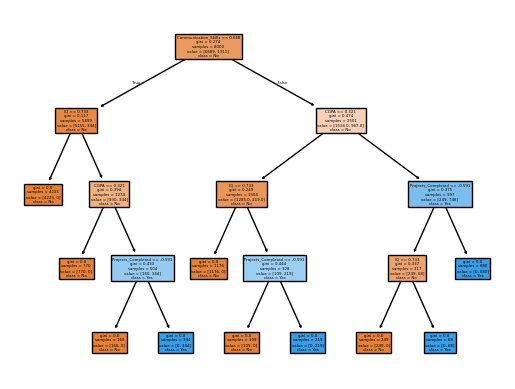

In [113]:
plot_tree(dt,feature_names=X.columns,class_names=y.unique(),filled=True)
plt.show()

In [114]:
train_pred = dt.predict(X_train)
accuracy_score(y_train,train_pred)

1.0

In [115]:
test_pred = dt.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,test_pred)

1.0

In [117]:
confusion_matrix(y_test,test_pred)

array([[1652,    0],
       [   0,  348]], dtype=int64)